In [1]:
import numpy as np
import matplotlib.pyplot as plt
import transport.dispersion as dispersion
import transport.orbitcreation as orbitcreation
import transport.conductivity as conductivity
from transport.makesigmalist import makelist_parallel,makelist_serial
from time import time

#repository_directory = "C:/Users/Sahas/OneDrive/Documents/PhD data/Modelling/Python code/boltzmann_transport_git/boltzmann_transport/"
repository_directory = "C:/Users/kamat/OneDrive/Documents/PhD data/Modelling/Python code/boltzmann_transport_git/boltzmann_transport/"

In [2]:

class FitTrajectory:
    def __init__(self):
        self.data = {}

    def add(self, paramsdict):
        for key, value in paramsdict.items():
            if key not in self.data:
                self.data[key] = []
            if isinstance(value, np.ndarray):
                self.data[key].append(value.copy())
            else:
                self.data[key].append(value)

    def save(self, filename):
        np.savez_compressed(
            filename,
            **{k: np.asarray(v) for k, v in self.data.items()}
        )

trajectory = FitTrajectory()

Time taken to create Fermi Surface = 0.06368255615234375
Doping = 0.23823958569583503%
Time taken to create B independent Amatrix =  0.5156724452972412
Theta=0. Calculated total area: 4.238851943607889. Number of orbits used 20. Size of Amatrix: 2000
Theta=0. Calculated total area: 4.238851943607889. Number of orbits used 20. Size of Amatrix: 2000
rho_xx = 20.35262626126801, rho_xy (9 T) = 0.477042823465033
execution time: 1.7424218654632568
Time taken to create B independent Amatrix =  0.5318901538848877
Theta=0. Calculated total area: 4.238851943607889. Number of orbits used 20. Size of Amatrix: 2000
Theta=0. Calculated total area: 4.238851943607889. Number of orbits used 20. Size of Amatrix: 2000
rho_xx = 20.35262626126801, rho_xy (9 T) = 0.477042823465033
execution time: 3.4119300842285156
Doping=0.23823958569583503


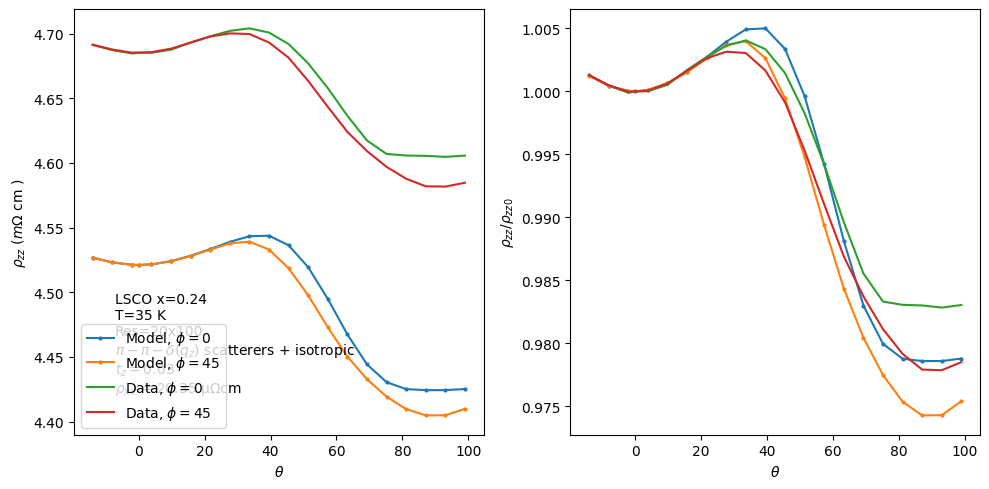

In [14]:
theta_min,theta_max,n_thetas = -14,99,20

starttime_global = time()
thetalist = np.sort(np.concatenate([np.linspace(theta_min,theta_max,n_thetas),[0]])) #list of 20 numbers from -14 to 99 but 0 is forced in there

res_z = 20
res_xy = 100
scatteringmodel="pipidelta_exp"
Tzmultvalue,invtau_iso,strength,spread_xy,n = 0.03335831504060885,9.1,17.910520030952803,0.124,4
#strength_fwd,spread_xy_fwd = 0.2,0.7
mumultvalue=0.81
T,T1multvalue,T11multvalue = 190e-3,-0.132,0.066

plotScattering=False

dispersionInstance = dispersion.LSCOdispersion(T= T,T1multvalue=T1multvalue,T11multvalue=T11multvalue,Tzmultvalue=Tzmultvalue,mumultvalue=mumultvalue)
FSorbitsInstance = orbitcreation.fermiSurfaceOrbits(res_z,res_xy,dispersionInstance,True)
starttime = time()
alpha = 0.1
FSorbitsInstance.createFS(tilingformat="variable",alpha=alpha,parallelised=False)
endtime = time() 
print(f"Time taken to create Fermi Surface = {endtime - starttime}")
doping = FSorbitsInstance.calculateDoping()

def create_rhozz(phi,Bmag,plotScattering=plotScattering):
    phi_rad = np.deg2rad(phi)
    conductivityInstance = conductivity.Conductivity(dispersionInstance,FSorbitsInstance,invtau_iso=invtau_iso,delta_in_k=True)
    starttime = time()
    conductivityInstance.createAmatrix_Bindependent_isotropic()

    conductivityInstance.create_Hfunc(scatteringmodel=scatteringmodel,strength=strength,spread_xy=spread_xy,n=n)
    conductivityInstance.createAmatrix_Bindependent_fwdscatter_out()
    conductivityInstance.createAmatrix_Bindependent_fwdscatter_in()

    #add some forward scattering
    #conductivityInstance.delta_in_k = False
    #conductivityInstance.create_Hfunc(scatteringmodel="crepe",strength=strength_fwd,spread_xy=spread_xy_fwd)
    #conductivityInstance.createAmatrix_Bindependent_fwdscatter_out()
    #conductivityInstance.createAmatrix_Bindependent_fwdscatter_in()

    if plotScattering: conductivityInstance.plotScatteringOut()
    endtime = time()
    print(f"Time taken to create B independent Amatrix =  {endtime - starttime}")

    def getsigma(theta,Bmag=Bmag):
        B = [Bmag*np.sin(np.deg2rad(theta))*np.cos(phi_rad),Bmag*np.sin(np.deg2rad(theta))*np.sin(phi_rad),Bmag*np.cos(np.deg2rad(theta))]
        conductivityInstance.createAmatrix_Bdependent(B)
        conductivityInstance.createAlpha()
        conductivityInstance.createSigma()

        print(f"Theta={theta}. Calculated total area: {conductivityInstance.areasum}. Number of orbits used {len(conductivityInstance.FSorbitsInstance.FSorbits)}. Size of Amatrix: {conductivityInstance.n}")
        return conductivityInstance.sigma,conductivityInstance.areasum


    sigmalist,rholist,arealist = makelist_parallel(getsigma,thetalist,workers=5)
    sigma_zero,area_zero = getsigma(theta=0,Bmag=0)
    sigma_9T,area_9T = getsigma(theta=0,Bmag=9)

    rho_zero = np.linalg.inv(sigma_zero)
    rho_9T = np.linalg.inv(sigma_9T)

    rhozzlist= [rho[2,2]*10e-5 for rho in rholist]
    print(f"rho_xx = {rho_zero[0,0]*10e-2}, rho_xy (9 T) = {rho_9T[0,1]*10e-2}")
    

    endtime_global = time()
    print(f"execution time: {endtime_global-starttime_global}")

    return rhozzlist,rho_zero,rho_9T

#p.savetxt("rhoxyvstPhi"+str(phi)+".dat",np.transpose([thetalist,rhoxylist]))

#generate data
rhozzlist0,rho_zero,rho_9T = create_rhozz(phi=0,Bmag=45)
rhozzlist45,_,_ = create_rhozz(phi=45,Bmag=45,plotScattering=False)

rhozz0list_normalized = rhozzlist0/rhozzlist0[np.argmin(thetalist**2)]
rhozz45list_normalized = rhozzlist45/rhozzlist45[np.argmin(thetalist**2)]

print(f"Doping={doping}")

#plot generated data
fig,axes = plt.subplots(nrows=1,ncols=2, figsize=(10, 5))

axes[0].plot(thetalist,rhozzlist0,ls="-",marker="o",ms=2,label=f"Model, $\phi=0$")
axes[0].plot(thetalist,rhozzlist45,ls="-",marker="o",ms=2,label=f"Model, $\phi=45$")
axes[1].plot(thetalist,rhozz0list_normalized,ls="-",marker="o",ms=2,label=f"Model, $\phi=0$")
axes[1].plot(thetalist,rhozz45list_normalized,ls="-",marker="o",ms=2,label=f"Model, $\phi=45$")

#load data
datafile_phi0 = f"data/admr_data/2511A/2511A_phi0_T35K_B45.0T.txt"
data_theta0,data_rhozz0 = np.loadtxt(repository_directory+datafile_phi0,unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
data_theta0,data_rhozz0 = data_theta0[np.argsort(data_theta0)],data_rhozz0[np.argsort(data_theta0)]
data_rhozz0_interp = np.interp(thetalist,data_theta0,data_rhozz0)
data_rhozz0_normalized = data_rhozz0_interp/data_rhozz0_interp[np.argmin(thetalist**2)]

datafile_phi45 = f"data/admr_data/2511A/2511A_phi45_T35K_B45.0T.txt"
data_theta45,data_rhozz45 = np.loadtxt(repository_directory+datafile_phi45,unpack=True,skiprows=1,delimiter=",",usecols=(0,1))
data_theta45,data_rhozz45 = data_theta45[np.argsort(data_theta45)],data_rhozz45[np.argsort(data_theta45)]
data_rhozz45_interp = np.interp(thetalist,data_theta45,data_rhozz45)
data_rhozz45_normalized = data_rhozz45_interp/data_rhozz45_interp[np.argmin(thetalist**2)]

#plot loaded data

axes[0].plot(thetalist,data_rhozz0_interp,ls="-",ms=2,label="Data, $\phi=0$")
axes[0].plot(thetalist,data_rhozz45_interp,ls="-",ms=2,label="Data, $\phi=45$")
axes[1].plot(thetalist,data_rhozz0_normalized,ls="-",ms=2,label="Data, $\phi=0$")
axes[1].plot(thetalist,data_rhozz45_normalized,ls="-",ms=2,label="Data, $\phi=45$")

axes[0].set_ylabel(r"$\rho_{zz}$ ($m\Omega$ cm )") 
axes[0].set_xlabel(r'$\theta$')
axes[0].text(0.1,0.1,f"LSCO x=0.24\nT=35 K\nRes={res_z}x{res_xy}\n$\pi-\pi-\delta(q_z)$ scatterers + isotropic\n$t_z = 0.03$\n$\\rho_{{xx}}$ = {rho_zero[0,0]*10e-2:.2f} μΩcm",fontsize=10, transform=axes[0].transAxes)
axes[0].legend()
axes[1].set_ylabel(r"$\rho_{zz}/\rho_{zz0}$") #($m\Omega$ cm )
axes[1].set_xlabel(r'$\theta$')

plt.tight_layout()
plt.show()

############# saving exhaustive information to npz file to create training data ##########################

paramsdict = {
    "theta_min":theta_min,
    "theta_max":theta_max,
    "n_thetas":n_thetas,
    "res_z":res_z,
    "res_xy":res_xy,
    "scatteringmodel":scatteringmodel,
    "Tzmultvalue":Tzmultvalue,
    "invtau_iso":invtau_iso,
    "strength":strength,
    "spread_xy":spread_xy,
    "n":n,
    "mumultvalue":mumultvalue,
    "T":T,
    "T1multvalue":T1multvalue,
    "T11multvalue":T11multvalue,
    "alpha":alpha,
    "doping":doping,
    "rho_xx":rho_zero[0,0]*10e-2,
    "rho_xy9T":rho_9T[0,1]*10e-2,
    "thetalist":thetalist,
    "rhozzlist0":rhozzlist0,
    "rhozzlist45":rhozzlist45,
    "rhozz0list_normalized":rhozz0list_normalized,
    "rhozz45list_normalized":rhozz45list_normalized,
    "datafile_phi0":datafile_phi0,
    "datafile_phi45":datafile_phi45,
    "data_theta0":data_theta0,
    "data_rhozz0":data_rhozz0,
    "data_rhozz0_interp":data_rhozz0_interp,
    "data_rhozz0_normalized":data_rhozz0_normalized,
    "data_theta45":data_theta45,
    "data_rhozz45":data_rhozz45,
    "data_rhozz45_interp":data_rhozz45_interp,
    "data_rhozz45_normalized":data_rhozz45_normalized
}

trajectory.add(paramsdict)

np.savetxt(
    "fit_24_30K.csv",
    np.column_stack((thetalist, rhozzlist0,rhozzlist45)),
    header="theta,rho (0 degree),rho (45 degree)",
    delimiter=","
)



In [4]:
##trajectory.save("fit010.npz")    

In [5]:
#f = np.load("fit010.npz", allow_pickle=True)
#strength = f["strength"]    
#print(strength)         